In [4]:
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np 
import pandas as pd 
import cartopy.crs as ccrs
import cmocean

In [5]:
from OceanDataStore import OceanDataCatalog

In [6]:
catalog = OceanDataCatalog(catalog_name="noc-model-stac")

MaxRetryError: HTTPSConnectionPool(host='noc-msm-o.s3-ext.jc.rl.ac.uk', port=443): Max retries exceeded with url: /oceandatastore/noc-model-stac/catalog.json (Caused by ConnectTimeoutError(<HTTPSConnection(host='noc-msm-o.s3-ext.jc.rl.ac.uk', port=443) at 0x1dfa076d590>, 'Connection to noc-msm-o.s3-ext.jc.rl.ac.uk timed out. (connect timeout=None)'))

In [ ]:
catalog.search(collection='noc-npd-era5', standard_name='sea_surface_temperature')

In [ ]:
catalog.available_items

In [6]:
catalog.Items[1]

<Item id=noc-npd-era5/npd-eorca1-era5v1/gn/T1m>

In [7]:
ds1 = catalog.open_dataset(id=catalog.Items[0].id,
                          start_datetime='1990-01',
                          end_datetime='2024-12')

ds1

<xarray.Dataset> Size: 28GB
Dimensions:                (time_counter: 35, y: 331, x: 360, deptht: 75,
                            axis_nbounds: 2)
Coordinates:
  * time_counter           (time_counter) datetime64[ns] 280B 1990-07-02T12:0...
  * deptht                 (deptht) float32 300B 0.5058 1.556 ... 5.902e+03
    nav_lon                (y, x) float64 953kB dask.array<chunksize=(331, 360), meta=np.ndarray>
    nav_lat                (y, x) float64 953kB dask.array<chunksize=(331, 360), meta=np.ndarray>
    time_centered          (time_counter) datetime64[ns] 280B dask.array<chunksize=(1,), meta=np.ndarray>
Dimensions without coordinates: y, x, axis_nbounds
Data variables: (12/74)
    berg_latent_heat_flux  (time_counter, y, x) float32 17MB dask.array<chunksize=(1, 331, 360), meta=np.ndarray>
    empmr                  (time_counter, y, x) float32 17MB dask.array<chunksize=(1, 331, 360), meta=np.ndarray>
    deptht_bounds          (deptht, axis_nbounds) float32 600B dask.array<chunksize=(25, 2), meta=np.ndarray>
    ficeberg               (time_counter, y, x) float32 17MB dask.array<chunksize=(1, 331, 360), meta=np.ndarray>
    evs                    (time_counter, y, x) float32 17MB dask.array<chunksize=(1, 331, 360), meta=np.ndarray>
    e3t                    (time_counter, deptht, y, x) float32 1GB dask.array<chunksize=(1, 25, 331, 360), meta=np.ndarray>
    ...                     ...
    vohflisf               (time_counter, deptht, y, x) float32 1GB dask.array<chunksize=(1, 25, 331, 360), meta=np.ndarray>
    vowflisf               (time_counter, deptht, y, x) float32 1GB dask.array<chunksize=(1, 25, 331, 360), meta=np.ndarray>
    zos                    (time_counter, y, x) float32 17MB dask.array<chunksize=(1, 331, 360), meta=np.ndarray>
    ttrd_qns_li            (time_counter, y, x) float32 17MB dask.array<chunksize=(1, 331, 360), meta=np.ndarray>
    vohfcisf               (time_counter, deptht, y, x) float32 1GB dask.array<chunksize=(1, 25, 331, 360), meta=np.ndarray>
    zossq                  (time_counter, y, x) float32 17MB dask.array<chunksize=(1, 331, 360), meta=np.ndarray>

In [11]:
ds1['so_abs']

<xarray.DataArray 'so_abs' (time_counter: 35, deptht: 75, y: 331, x: 360)> Size: 1GB
dask.array<getitem, shape=(35, 75, 331, 360), dtype=float32, chunksize=(1, 25, 331, 360), chunktype=numpy.ndarray>
Coordinates:
  * time_counter   (time_counter) datetime64[ns] 280B 1990-07-02T12:00:00 ......
  * deptht         (deptht) float32 300B 0.5058 1.556 ... 5.698e+03 5.902e+03
    nav_lat        (y, x) float64 953kB dask.array<chunksize=(331, 360), meta=np.ndarray>
    nav_lon        (y, x) float64 953kB dask.array<chunksize=(331, 360), meta=np.ndarray>
    time_centered  (time_counter) datetime64[ns] 280B dask.array<chunksize=(1,), meta=np.ndarray>
Dimensions without coordinates: y, x
Attributes:
    standard_name:       sea_water_absolute_salinity
    long_name:           sea_water_absolute_salinity
    units:               g/kg
    online_operation:    average
    interval_operation:  1 yr
    interval_write:      1 yr
    cell_methods:        time: mean

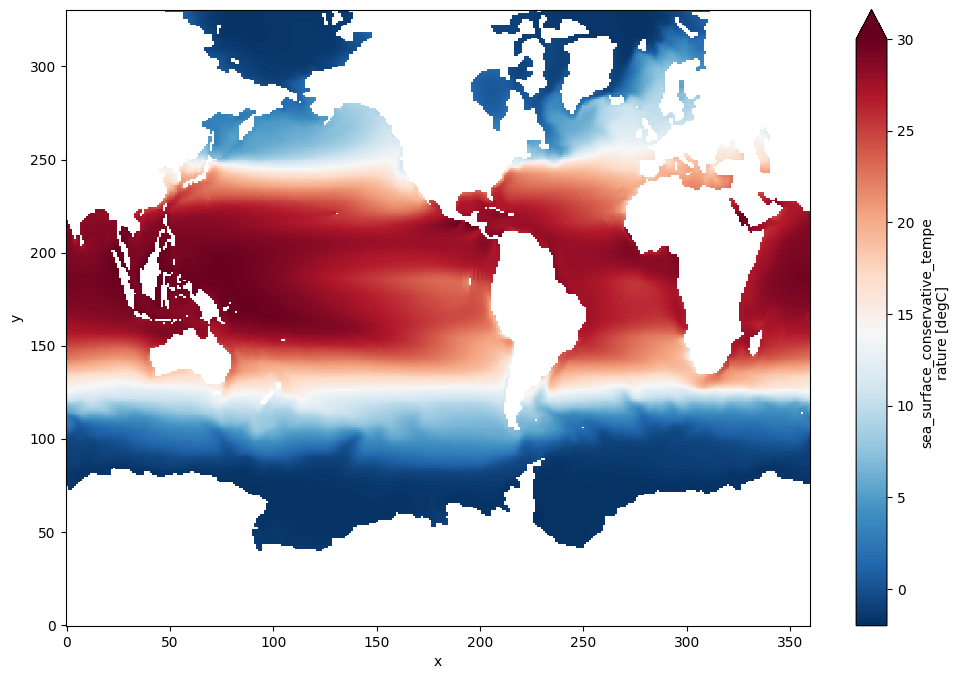

In [9]:
## Plotting with default method 

ds1['tos_con'].mean(dim='time_counter').plot(cmap='RdBu_r', figsize = (12,8), vmin = -2, vmax = 30)


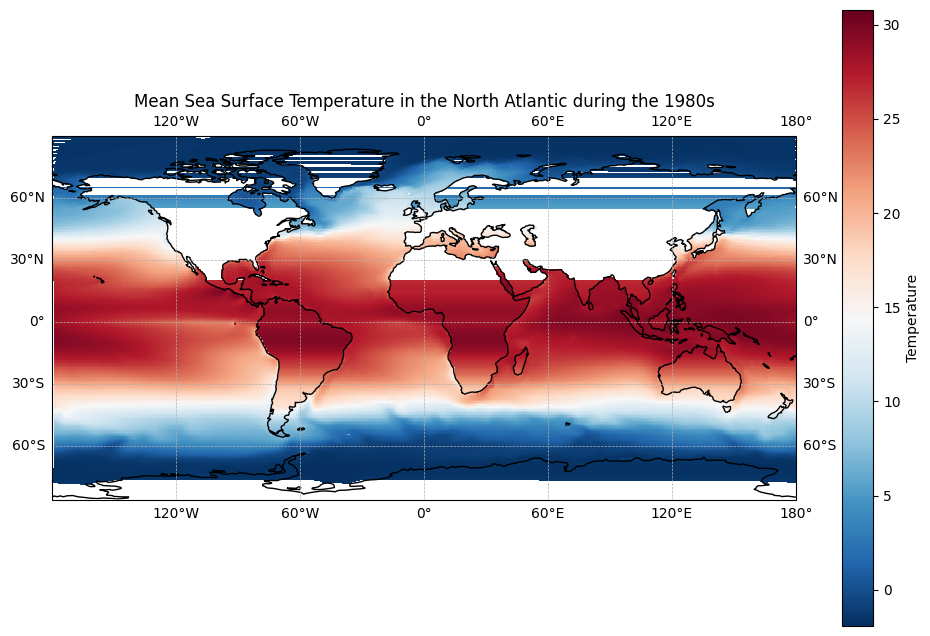

In [10]:
## Plotting North Atlantic using cartopy 

fig, ax = plt.subplots(figsize=(12, 8), subplot_kw={'projection': ccrs.PlateCarree()})

data = ds1['tos_con'].mean(dim='time_counter')
im = ax.pcolormesh(ds1['nav_lon'],  ds1['nav_lat'], data, cmap='RdBu_r', transform=ccrs.PlateCarree())
cl = ax.coastlines()
gl = ax.gridlines(draw_labels=True, linewidth=0.5, linestyle='--')
ax.set_title('Mean Sea Surface Temperature in the North Atlantic during the 1980s')

plt.colorbar(im, ax=ax, label='Temperature')
plt.show()

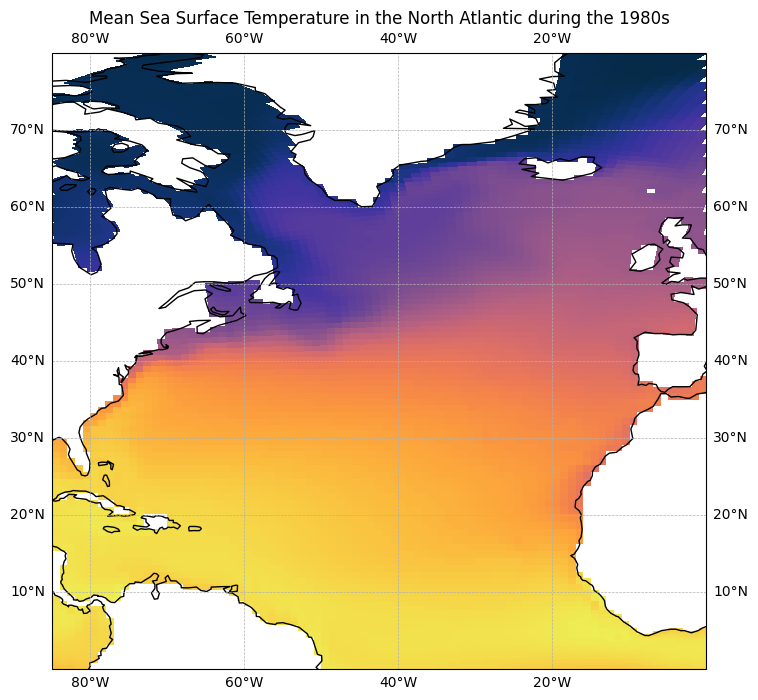

In [12]:
ds2 = catalog.open_dataset(id=catalog.Items[1].id,
                          start_datetime='1990-01',
                          end_datetime='2024-12',
                          bbox = (-85.0, 0.0, 0.0, 80.0))

fig, ax = plt.subplots(figsize=(12, 8), subplot_kw={'projection': ccrs.PlateCarree()})
data = ds2['tos_con'].mean(dim='time_counter')
im = ax.pcolormesh(ds2['nav_lon'],  ds2['nav_lat'], data, cmap=cmocean.cm.thermal, transform=ccrs.PlateCarree(), vmin = -3, vmax = 30)
ax.coastlines()
ax.gridlines(draw_labels=True, linewidth=0.5, linestyle='--')
ax.set_title('Mean Sea Surface Temperature in the North Atlantic during the 1980s')
ax.set_extent([-85.0, 0.0, 0.0, 80.0], crs=ccrs.PlateCarree())

plt.show()

In [13]:
ds2

<xarray.Dataset> Size: 33GB
Dimensions:                (time_counter: 420, y: 135, x: 85, deptht: 75,
                            axis_nbounds: 2)
Coordinates:
  * time_counter           (time_counter) datetime64[ns] 3kB 1990-01-16T12:00...
  * deptht                 (deptht) float32 300B 0.5058 1.556 ... 5.902e+03
    nav_lon                (y, x) float64 92kB -84.5 -83.5 -82.5 ... 45.74 46.87
    nav_lat                (y, x) float64 92kB 0.0 0.0 0.0 ... 80.05 79.65 79.25
    time_centered          (time_counter) datetime64[ns] 3kB dask.array<chunksize=(1,), meta=np.ndarray>
Dimensions without coordinates: y, x, axis_nbounds
Data variables: (12/74)
    berg_latent_heat_flux  (time_counter, y, x) float32 19MB dask.array<chunksize=(1, 135, 85), meta=np.ndarray>
    hfds                   (time_counter, y, x) float32 19MB dask.array<chunksize=(1, 135, 85), meta=np.ndarray>
    e3t                    (time_counter, deptht, y, x) float32 1GB dask.array<chunksize=(1, 25, 135, 85), meta=np.ndarray>
    empmr                  (time_counter, y, x) float32 19MB dask.array<chunksize=(1, 135, 85), meta=np.ndarray>
    ficeberg               (time_counter, y, x) float32 19MB dask.array<chunksize=(1, 135, 85), meta=np.ndarray>
    fsitherm               (time_counter, y, x) float32 19MB dask.array<chunksize=(1, 135, 85), meta=np.ndarray>
    ...                     ...
    ttrd_atf_li            (time_counter, deptht, y, x) float32 1GB dask.array<chunksize=(1, 25, 135, 85), meta=np.ndarray>
    vohfcisf               (time_counter, deptht, y, x) float32 1GB dask.array<chunksize=(1, 25, 135, 85), meta=np.ndarray>
    vohflisf               (time_counter, deptht, y, x) float32 1GB dask.array<chunksize=(1, 25, 135, 85), meta=np.ndarray>
    zossq                  (time_counter, y, x) float32 19MB dask.array<chunksize=(1, 135, 85), meta=np.ndarray>
    vowflisf               (time_counter, deptht, y, x) float32 1GB dask.array<chunksize=(1, 25, 135, 85), meta=np.ndarray>
    zos                    (time_counter, y, x) float32 19MB dask.array<chunksize=(1, 135, 85), meta=np.ndarray>

In [16]:
print("data.shape:", data.shape)
print("nav_lon.shape:", ds1['nav_lon'].shape)
print("nav_lat.shape:", ds1['nav_lat'].shape)
print("lon min/max:", ds1['nav_lon'].min().values, ds1['nav_lon'].max().values)
print("lat min/max:", ds1['nav_lat'].min().values, ds1['nav_lat'].max().values)

data.shape: (331, 360)
nav_lon.shape: (331, 360)
nav_lat.shape: (331, 360)
lon min/max: -179.99653278676575 179.99031297181477
lat min/max: -85.78874492732504 89.7417689202141


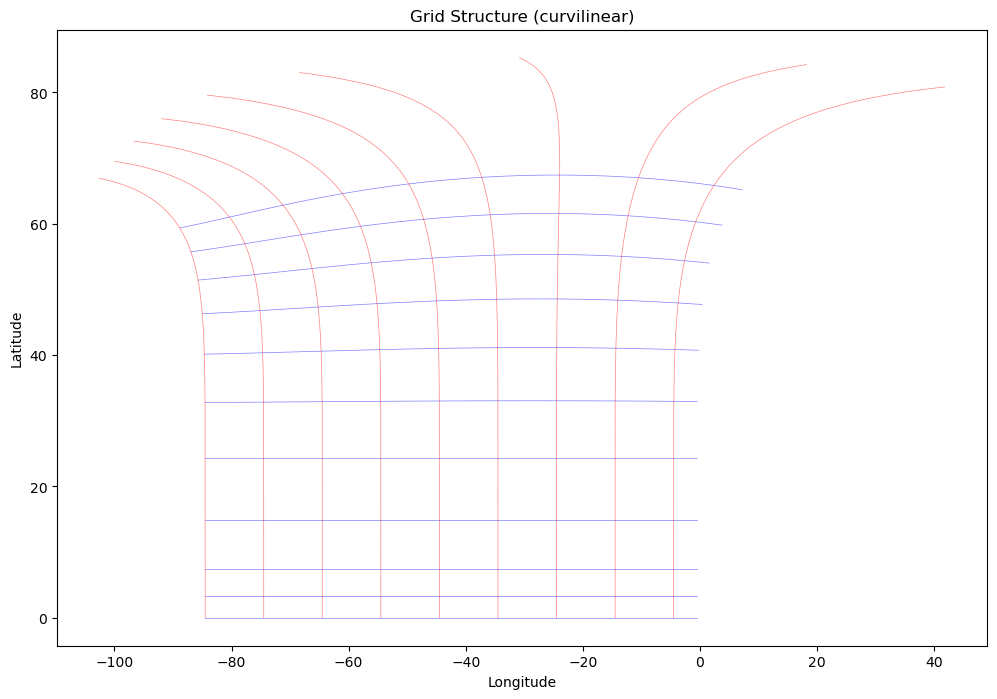

In [15]:
#### What does a Curvilinear grid look like?

import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 8))

for i in range(0, 106, 10):
    ax.plot(ds2['nav_lon'][i, :], ds2['nav_lat'][i, :], 'b-', alpha=0.5, linewidth=0.5)
    
for j in range(0, 90, 10):
    ax.plot(ds2['nav_lon'][:, j], ds2['nav_lat'][:, j], 'r-', alpha=0.5, linewidth=0.5)

ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title('Grid Structure (curvilinear)')
plt.show()